In [4]:
import ee
import geemap

# 1. 초기화
ee.Initialize(project='team5prjt')

# 2. 지도 생성
Map = geemap.Map()

# 3. 좌표 설정 (부산항)
busan_port = ee.Geometry.Point([129.0756, 35.1046])

# 4. 데이터셋 불러오기 (★ HARMONIZED로 변경)
image = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(busan_port)
    .filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
    .first())

# 5. 지도에 레이어 추가
Map.centerObject(busan_port, 13)
Map.addLayer(image, {'min': 0, 'max': 3000, 'bands': ['B4', 'B3', 'B2']}, 'Busan Port RGB')

# 6. 지도 출력
Map

Map(center=[35.1046, 129.0756], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

In [5]:
import ee

# 1. 초기화 (team5prjt 사용)
ee.Initialize(project='team5prjt')

# 2. 영역 및 이미지 정의 (이전과 동일)
korea_bounds = ee.Geometry.Rectangle([125.0, 33.0, 131.0, 38.5])
dataset = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(korea_bounds)
    .filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))
korea_image = dataset.median().clip(korea_bounds)

# 3. ★ 핵심: 지도로 띄우지 않고, 구글 드라이브로 Export 명령 내리기
task = ee.batch.Export.image.toDrive(
    image=korea_image.select(['B4', 'B3', 'B2']), # RGB 채널만 추출
    description='South_Korea_2024_100m',         # 파일 이름
    folder='EarthEngine_Data',                   # 구글 드라이브 내 생성될 폴더명
    scale=100,                                   # 해상도 (10m는 너무 커서 100m로 우선 테스트 권장)
    region=korea_bounds,
    maxPixels=1e13                               # 메모리 제한 해제 (중요: 대용량 처리 허용)
)

# 4. 작업 시작
task.start()
print("구글 드라이브로 내보내기 작업이 시작되었습니다. (백그라운드에서 실행됨)")

구글 드라이브로 내보내기 작업이 시작되었습니다. (백그라운드에서 실행됨)


In [7]:
import ee

# 1. 초기화 (team5prjt)
ee.Initialize(project='team5prjt')

# 2. 내 계정에서 실행된 최근 작업(Task) 목록 가져오기
tasks = ee.batch.Task.list()

# 3. 가장 최근 작업 3개의 상태 출력
print("=== 구글 서버 작업 진행 상태 ===")
for task in tasks[:3]: 
    status = task.status()
    print(f"작업 이름: {status.get('description', '이름 없음')}")
    print(f"현재 상태: {status['state']}")
    
    # 에러가 났다면 에러 메시지도 출력
    if status['state'] == 'FAILED':
        print(f"에러 원인: {status.get('error_message')}")
    print("-" * 30)

=== 구글 서버 작업 진행 상태 ===
작업 이름: South_Korea_2024_100m
현재 상태: RUNNING
------------------------------


In [1]:
import torch
import tifffile
import numpy as np

# 1. 다운로드한 위성 사진 파일 이름
file_path = "South_Korea_2024_100m.tif"

try:
    # 2. 하드디스크에 있는 파일을 RAM(넘파이 배열)으로 읽어오기
    # 바로 이 부분이 빠져있어서 아까 NameError가 났던 것입니다.
    numpy_satellite_array = tifffile.imread(file_path)
    print(f"이미지 불러오기 성공! 크기: {numpy_satellite_array.shape}")
    
    # 3. 내 컴퓨터에 맞는 최적의 장치(GPU) 자동으로 찾기
    if torch.cuda.is_available():
        device = torch.device("cuda")  # 윈도우 NVIDIA GPU
        print("NVIDIA GPU(CUDA)가 활성화되었습니다.")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")   # 애플 M1/M2/M3 GPU
        print("Apple M-Series GPU(MPS)가 활성화되었습니다.")
    else:
        device = torch.device("cpu")
        print("GPU를 찾을 수 없어 CPU를 사용합니다.")

    # 4. RAM에 있던 데이터를 GPU(VRAM) 전용 텐서로 변환하여 밀어넣기
    # 딥러닝 연산은 주로 float32를 쓰기 때문에 데이터 타입도 맞춰줍니다.
    tensor_image = torch.from_numpy(numpy_satellite_array.astype(np.float32)).to(device)
    
    print(f"데이터가 성공적으로 {device} 메모리에 올라갔습니다!")
    print(f"텐서 크기: {tensor_image.shape}")

except FileNotFoundError:
    print(f"앗, '{file_path}' 파일을 찾을 수 없습니다. 구글 드라이브에서 다운로드 후 같은 폴더에 넣어주세요.")

이미지 불러오기 성공! 크기: (6166, 6680, 3)
NVIDIA GPU(CUDA)가 활성화되었습니다.
데이터가 성공적으로 cuda 메모리에 올라갔습니다!
텐서 크기: torch.Size([6166, 6680, 3])


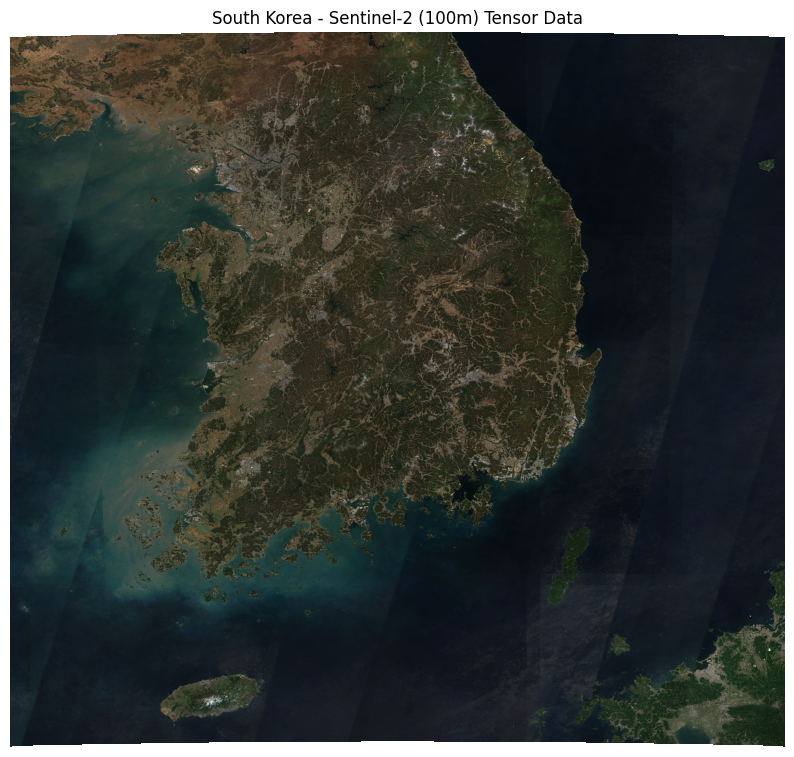

In [2]:
import matplotlib.pyplot as plt

# 1. 텐서를 다시 넘파이로 내리고 (그림판은 CPU를 쓰기 때문), CPU 메모리로 이동
img_data = tensor_image.cpu().numpy()

# 2. 정규화 (Normalization): 0~10000 대의 값을 0~1 사이로 스케일링
img_display = img_data / 3000.0
img_display = np.clip(img_display, 0, 1) # 1을 초과하는 눈부신 값은 1로 깎아냄

# 3. 그림 띄우기
plt.figure(figsize=(10, 10))
plt.imshow(img_display)
plt.title("South Korea - Sentinel-2 (100m) Tensor Data")
plt.axis('off')
plt.show()

잘라낸 송파구 텐서 크기: torch.Size([300, 300, 3])


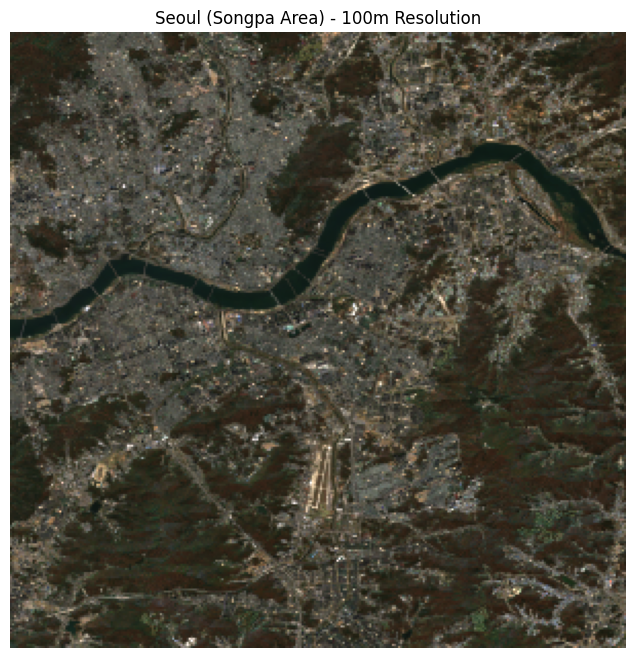

In [3]:
import matplotlib.pyplot as plt

# 1. 텐서 슬라이싱 (도마 위에서 칼로 썰기)
# 문법: tensor[세로_시작:세로_끝, 가로_시작:가로_끝, 채널]
# 송파구/강남구 부근을 넉넉하게 300x300 픽셀(가로세로 30km)로 잘라냅니다.
songpa_patch_tensor = tensor_image[1000:1300, 2200:2500, :]

print(f"잘라낸 송파구 텐서 크기: {songpa_patch_tensor.shape}") 
# 예상 출력: torch.Size([300, 300, 3])

# 2. 화면에 띄우기 위해 NumPy로 변환 및 정규화
songpa_patch_numpy = songpa_patch_tensor.cpu().numpy()
songpa_display = songpa_patch_numpy / 3000.0
songpa_display = np.clip(songpa_display, 0, 1)

# 3. 그림 그리기
plt.figure(figsize=(8, 8))
plt.imshow(songpa_display)
plt.title("Seoul (Songpa Area) - 100m Resolution")
plt.axis('off')
plt.show()

In [4]:
import ee

# 1. 초기화 (team5prjt 프로젝트 사용)
ee.Initialize(project='team5prjt')

# 2. 송파구 주변의 정확한 Bounding Box (위도/경도 좌표) 지정
# [서쪽 경도, 남쪽 위도, 동쪽 경도, 북쪽 위도]
songpa_bounds = ee.Geometry.Rectangle([127.08, 37.47, 127.15, 37.53])

# 3. 데이터셋 불러오기 (조건: 송파구 영역, 2024년 1년치, 구름 20% 미만)
dataset = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(songpa_bounds)
    .filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

# 4. 중간값(median)으로 구름을 걷어내고, 정확히 송파구 네모 모양으로 자르기(clip)
songpa_10m_image = dataset.median().clip(songpa_bounds)

# 5. 구글 드라이브로 내보내기 (Export Task)
task = ee.batch.Export.image.toDrive(
    image=songpa_10m_image.select(['B4', 'B3', 'B2']), # RGB 채널 추출
    description='Seoul_Songpa_2024_10m',               # 저장될 파일 이름
    folder='EarthEngine_Data',                         # 드라이브 폴더명
    scale=10,                                          # ★ 핵심: 10m 최고 해상도 지정
    region=songpa_bounds,
    maxPixels=1e10                                     # 영역이 작으므로 넉넉하게 설정
)

# 6. 작업 시작 명령
task.start()
print("🚀 송파구 10m 고해상도 데이터 추출이 구글 서버에서 시작되었습니다!")
print("구글 드라이브(EarthEngine_Data 폴더)를 확인해 주세요.")

🚀 송파구 10m 고해상도 데이터 추출이 구글 서버에서 시작되었습니다!
구글 드라이브(EarthEngine_Data 폴더)를 확인해 주세요.


✅ 원본 송파구 텐서: torch.Size([3, 669, 780])
✅ AI 입력용 패치 묶음: torch.Size([6, 3, 256, 256])


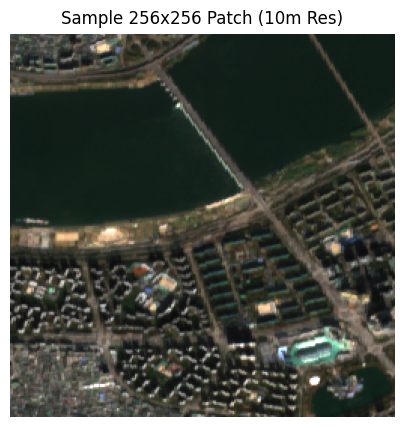

In [5]:
import torch
import tifffile
import numpy as np
import matplotlib.pyplot as plt

# 1. 파일 불러오기 및 장치 설정
file_path = "Seoul_Songpa_2024_10m.tif"
numpy_arr = tifffile.imread(file_path)

if torch.cuda.is_available(): device = torch.device("cuda")
elif torch.backends.mps.is_available(): device = torch.device("mps")
else: device = torch.device("cpu")

# 2. 텐서 변환 및 정규화 (Normalization)
tensor_img = torch.from_numpy(numpy_arr.astype(np.float32)).to(device)
tensor_img = tensor_img / 3000.0  # 0~10000 범위의 반사율을 0~1로 압축
tensor_img = torch.clamp(tensor_img, 0, 1) # 1을 초과하는 이상치(구름 등) 잘라내기

# 3. 차원 순서 변경 (Permute)
# 현재: [세로(H), 가로(W), 채널(C)] -> 변경: [채널(C), 세로(H), 가로(W)]
tensor_img = tensor_img.permute(2, 0, 1)

# 4. 256x256 패치로 깍둑썰기 (Unfold)
patch_size = 256
stride = 256 # 256픽셀씩 이동하며 자름 (겹치지 않게)

# H(세로, 차원 인덱스 1)와 W(가로, 차원 인덱스 2)를 따라 패치를 추출
patches = tensor_img.unfold(1, patch_size, stride).unfold(2, patch_size, stride)

# 5. 딥러닝 입력 표준 차원인 [B(배치), C(채널), H(세로), W(가로)] 로 재배열
C = patches.shape[0]
# 메모리를 일렬로 정렬(contiguous)한 뒤 차원 병합(view)
patches = patches.contiguous().view(C, -1, patch_size, patch_size) 
# 최종적으로 [B, C, H, W] 순서로 변경
final_batch = patches.permute(1, 0, 2, 3) 

print(f"✅ 원본 송파구 텐서: {tensor_img.shape}")
print(f"✅ AI 입력용 패치 묶음: {final_batch.shape}")
# 예상 출력 형태: torch.Size([N, 3, 256, 256]) (N은 생성된 패치의 개수)

# 6. 검증: 첫 번째 패치(index 0) 눈으로 확인하기
sample_patch = final_batch[0].cpu().permute(1, 2, 0).numpy() # 그리기 위해 다시 [H, W, C]로 복귀

plt.figure(figsize=(5, 5))
plt.imshow(sample_patch)
plt.title("Sample 256x256 Patch (10m Res)")
plt.axis('off')
plt.show()

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class SatelliteDetectionDataset(Dataset):
    def __init__(self, image_tensor, label_data=None):
        """
        image_tensor: 우리가 아까 만든 [N, 3, 256, 256] 형태의 위성 패치 묶음
        label_data: 각 패치에 해당하는 Bounding Box 좌표들 (현재는 없으므로 None)
        """
        # 차원 확인 및 저장
        self.images = image_tensor
        self.labels = label_data
        
        # 총 패치의 개수 (N)
        self.num_samples = self.images.shape[0]

    def __len__(self):
        # 딥러닝 모델이 "데이터가 총 몇 개야?"라고 물어볼 때 대답해주는 함수
        return self.num_samples

    def __getitem__(self, idx):
        # 딥러닝 모델이 "idx번째 데이터 줘!"라고 할 때 작동하는 함수
        # 1. idx 번째 256x256 이미지 패치를 꺼냅니다.
        img = self.images[idx]
        
        # 2. 정답지가 있다면 같이 꺼내고, 없다면 빈 텐서를 반환합니다.
        if self.labels is not None:
            # 보통 객체 탐지 라벨은 [객체 개수, 5] 형태입니다. (x, y, w, h, class)
            target = self.labels[idx] 
        else:
            # 추론(테스트) 모드일 때는 정답이 없으므로 더미(Dummy) 데이터를 줍니다.
            target = torch.zeros((0, 5)) 

        # 모델이 소화할 수 있게 딕셔너리나 튜플 형태로 깔끔하게 반환
        return img, target

# ==========================================
# 🚀 파이프라인 가동 테스트
# ==========================================

# 1. 우리가 아까 만든 final_batch 텐서를 데이터셋에 넣습니다.
# (현재는 정답지가 없으므로 이미지만 넣습니다)
my_dataset = SatelliteDetectionDataset(image_tensor=final_batch)

# 2. DataLoader: 컨베이어 벨트 생성
# batch_size=16: 한 번에 16장의 패치를 GPU에 던져줍니다.
# shuffle=True: 학습 시 데이터의 순서를 섞어서 모델이 순서를 외우지 못하게 합니다.
train_loader = DataLoader(my_dataset, batch_size=16, shuffle=True)

# 3. 컨베이어 벨트가 잘 돌아가는지 첫 번째 묶음(Batch)만 뽑아보기
for batch_images, batch_targets in train_loader:
    print(f"📦 GPU로 올라갈 이미지 배치의 크기: {batch_images.shape}")
    # 예상 출력: torch.Size([16, 3, 256, 256])
    print(f"🎯 짝지어진 정답지(Target)의 형태: {batch_targets.shape}")
    break # 테스트니까 한 번만 돌고 정지

📦 GPU로 올라갈 이미지 배치의 크기: torch.Size([6, 3, 256, 256])
🎯 짝지어진 정답지(Target)의 형태: torch.Size([6, 0, 5])



0: 640x640 (no detections), 44.8ms
Speed: 5.2ms preprocess, 44.8ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)


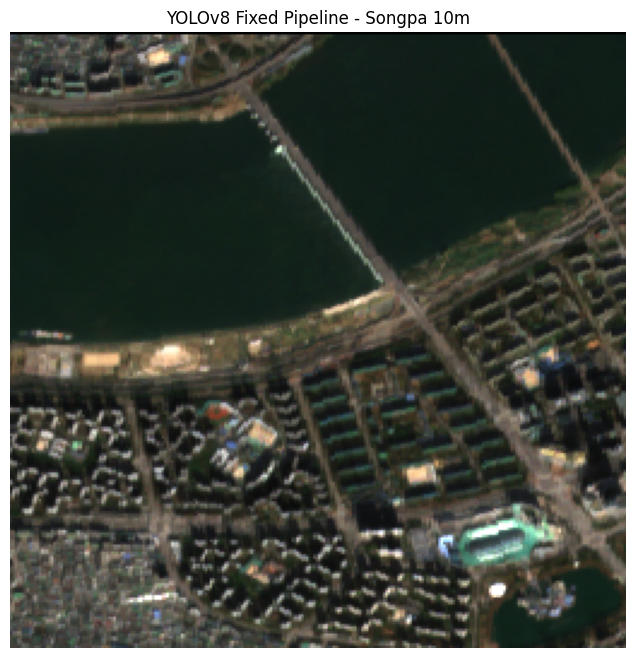

In [8]:
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt

# 1. 모델 로드
model = YOLO('yolov8n.pt')

# 2. 데이터 정제 (NaN 제거 및 타입 변환)
# np.nan_to_num: 숫자가 아닌 값(NaN)을 0으로 바꿔 안전하게 만듭니다.
clean_patch = np.nan_to_num(sample_patch)

# 0~255 범위로 변환 후 정수형으로 캐스팅
img_for_yolo = (clean_patch * 255).astype(np.uint8)

# 3. ★ 핵심: 메모리 재정렬 (Contiguous 적용)
# np.ascontiguousarray: 메모리에 흩어진 데이터를 한 줄로 예쁘게 새로 복사해서 정리합니다.
img_for_yolo = np.ascontiguousarray(img_for_yolo)

# 4. 모델 추론
results = model(img_for_yolo)

# 5. 결과 시각화
# 이제 에러 없이 실행됩니다.
annotated_img = results[0].plot()

# 6. 화면 출력
plt.figure(figsize=(8, 8))
plt.imshow(annotated_img)
plt.title("YOLOv8 Fixed Pipeline - Songpa 10m")
plt.axis('off')
plt.show()

In [14]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import time

# 옵션 설정
chrome_options = Options()
# 크롬 창 띄워서 직접 눈으로 확인하는게 마음 편함 (나중에 다듬어지면 숨기기)
# chrome_options.add_argument("--headless") 

driver = webdriver.Chrome(options=chrome_options)
driver.get("https://www.daangn.com/search/폴로%20셔츠")

# 인터넷 속도랑 서버 응답때문에 넉넉하게 5초 대기 (이게 은근 중요함)
time.sleep(5) 

print("=== 데이터 수집 시작 ===")

# 더보기 버튼 누르기 (일단 5번만 테스트)
for i in range(5):  
    try:
        # 클래스 이름 대신 텍스트로 버튼 찾기 (구글링 꿀팁: XPath 활용)
        more_btn = driver.find_element(By.XPATH, "//*[contains(text(), '더보기')]")
        more_btn.click()
        print(f"{i+1}번째 더보기 클릭 성공!")
        
        # 누르고 나서 새 데이터 뜰 때까지 무조건 기다려주기
        time.sleep(3) 
    except:
        print("더보기 버튼을 못 찾았거나 끝까지 다 왔나봐요. 반복문 탈출!")
        break

# 빈 리스트 만들기
item_list = []

# 게시글 태그 찾기 (article 태그로 통째로 가져오기)
articles = driver.find_elements(By.TAG_NAME, "article")
print(f"화면에 뜬 게시물 갯수: {len(articles)}개")

# 긁어온 게시물에서 필요한 것만 빼내기
for idx, article in enumerate(articles):
    try:
        # 제목
        title = article.find_element(By.CSS_SELECTOR, ".article-title").text
        # 가격
        price = article.find_element(By.CSS_SELECTOR, ".article-price").text
        
        # 이미지는 img 태그에서 src 속성 빼오기
        img_tag = article.find_element(By.TAG_NAME, "img")
        img_url = img_tag.get_attribute("src")

        item_list.append([title, price, img_url])
        
    except Exception as e:
        # 가끔 광고나 사진 없는 이상한 매물 껴있으면 에러나니까 걍 무시
        # print(f"{idx}번째 에러나서 패스") 
        pass

driver.quit()

print("=== 수집 결과 ===")
for item in item_list[:5]:
    print(item)
print(f"총 {len(item_list)}개 수집 완료!")

=== 데이터 수집 시작 ===
1번째 더보기 클릭 성공!
2번째 더보기 클릭 성공!
3번째 더보기 클릭 성공!
4번째 더보기 클릭 성공!
5번째 더보기 클릭 성공!
화면에 뜬 게시물 갯수: 0개
=== 수집 결과 ===
총 0개 수집 완료!


In [ ]:
import pandas as pd
import time
import os
from datetime import datetime
from firecrawl import FirecrawlApp
from pydantic import BaseModel, Field
from typing import List, Optional

# Firecrawl API 키 설정 (발급받은 키)
FIRECRAWL_API_KEY = "fc-fe305164e19f4d1095e908d0330976c8"
app = FirecrawlApp(api_key=FIRECRAWL_API_KEY)

# 1. Firecrawl LLM Extract를 위한 스키마(구조) 정의
class DaangnItem(BaseModel):
    article_id: str = Field(description="상품 상세 링크의 숫자 ID 번호")
    title: str = Field(description="상품명 (예: 폴로 랄프로렌 셔츠)")
    price: str = Field(description="상품 가격 숫자만 (예: 35000)")
    status: str = Field(description="현재 상태 (판매중, 예약중, 판매완료 중 하나)")
    upload_time_str: str = Field(description="표시된 업로드 시간 (예: 10분 전, 끌올 1일전)")
    image_url: str = Field(description="첫 번째 상품 이미지 절대 경로 URL")

class DaangnExtractSchema(BaseModel):
    items: List[DaangnItem]

# 2. 크롤링 함수 정의 (폴로 키워드 검색)
def scrape_polo_items(pages=3):
    scraped_data = []
    
    for page in range(1, pages + 1):
        print(f"[{page}/{pages}] 페이지 당근마켓 데이터 추출 중...\n")
        url = f"https://www.daangn.com/search/%ED%8F%B4%EB%A1%9C?page={page}"
        
        try:
            result = app.scrape(
                url, 
                formats=[{
                    'type': 'json',
                    'schema': DaangnExtractSchema.model_json_schema(),
                    'prompt': "당근마켓 페이지의 검색결과 목록에서 '폴로' 상품들의 ID, 이름, 가격, 판매상태, 등록시간, 사진URL을 모두 추출해줘."
                }],
                wait_for=3000
            )
            
            if hasattr(result, 'json') and result.json and 'items' in result.json:
                items = result.json['items']
                scraped_data.extend(items)
                print(f" -> 성공적으로 {len(items)}개의 아이템을 추출했습니다.\n")
            else:
                print(" -> 추출된 데이터가 없습니다.\n")
                
        except Exception as e:
            print(f"오류 발생: {e}\n")
            
        time.sleep(2)
        
    return scraped_data

# 3. 판매 소요 시간(Time to Sell) 추적을 위한 데이터베이스 갱신 로직
DB_FILE = 'daangn_polo_tracker.csv'

def update_dataset(new_items):
    current_time = datetime.now()
    
    new_df = pd.DataFrame(new_items)
    if new_df.empty:
        return None
        
    new_df['last_checked'] = current_time
    
    if os.path.exists(DB_FILE):
        db_df = pd.read_csv(DB_FILE)
        
        for index, row in new_df.iterrows():
            item_id = str(row['article_id'])
            
            mask = db_df['article_id'].astype(str) == item_id
            if mask.any():
                old_status = db_df.loc[mask, 'status'].values[0]
                new_status = row['status']
                
                if old_status in ['판매중', '예약중'] and new_status == '판매완료':
                    if pd.isna(db_df.loc[mask, 'sold_out_time'].values[0]):
                        db_df.loc[mask, 'sold_out_time'] = current_time
                        print(f"🎉 상품 판매 완료 감지!: {row['title']}\n")
                
                db_df.loc[mask, 'status'] = new_status
                db_df.loc[mask, 'last_checked'] = current_time
                db_df.loc[mask, 'upload_time_str'] = row['upload_time_str']
                
            else:
                row['first_seen_time'] = current_time
                row['sold_out_time'] = None
                db_df = pd.concat([db_df, pd.DataFrame([row])], ignore_index=True)
                
    else:
        new_df['first_seen_time'] = current_time
        new_df['sold_out_time'] = None
        db_df = new_df
        
    db_df.to_csv(DB_FILE, index=False, encoding='utf-8-sig')
    print(f"데이터셋 업데이트 완료! 총 누적 아이템: {len(db_df)}개\n")
    return db_df

print("당근마켓 수집 엔진 가동...\n")
fetched_items = scrape_polo_items(pages=10)
final_df = update_dataset(fetched_items)

if final_df is not None:
    display(final_df.head())

당근마켓 수집 엔진 가동...

[1/10] 페이지 당근마켓 데이터 추출 중...

 -> 성공적으로 9개의 아이템을 추출했습니다.

[2/10] 페이지 당근마켓 데이터 추출 중...

 -> 성공적으로 14개의 아이템을 추출했습니다.

[3/10] 페이지 당근마켓 데이터 추출 중...

 -> 성공적으로 10개의 아이템을 추출했습니다.

[4/10] 페이지 당근마켓 데이터 추출 중...

